
# Superstore Sales Analysis

## Business Objective
This project aims to analyse regional sales performance, profitability and the impact of discount strategies on business margins.



## 1. Data Overview
In this section, we load and explore the dataset to understand its structure.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#dataset upload

df = pd.read_csv('superstore.csv')

#Preview data

df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [2]:
# do we have nulls?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [3]:
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


## 2. Regional Performance Analysis
We analyse total sales and profit by region to identify top-performing markets.


## Wich region generates more sales sales and profit? ##



*   Sales by region




In [4]:
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(sales_by_region)

Region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
EMEA               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: Sales, dtype: int64


As a result we see Central domains in the sales, nearly doubling South, is this because its sells more or the prices are higher?.

We can se that the last one is Canada



*   Is it the region with more sales the one that has more profits?




In [5]:
profit_by_region = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
print(profit_by_region)


Region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           120089.11200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: Profit, dtype: float64


## 3. Profitability Analysis
We calculate profit margins to assess operational efficiency across regions.


We can see that Central also rules in the profits, but t¡South goes down no 4 position. This could be because it sells a lot but does not generate as much profit. This is why we have to look at the Profit Margin, how much benefit i get from what i sell.



*   Profit Margin = Profit / Sales




In [11]:
region_summary = df.groupby("Region")[["Sales","Profit"]].sum()
region_summary["Profit Margin"]= region_summary["Profit"]/region_summary["Sales"]
region_summary.sort_values(by="Profit Margin", ascending=False)


,Sales,Profit,Profit Margin
Region,,,
Canada,66932,17817.39000,0.266201
North Asia,848349,165578.42100,0.195177
Central Asia,752839,132480.18700,0.175974
North,1248192,194597.95252,0.155904
West,725514,108418.44890,0.149437
East,678834,91522.78000,0.134824
Africa,783776,88871.63100,0.113389
Central,2822399,311403.98164,0.110333
Oceania,1100207,120089.11200,0.109151


As we can see in here Canada is the region wich ha smore margin, meaning for each euro they win they get 0.26$ of benefit, a lot comparing to other regions.



*   Graphic



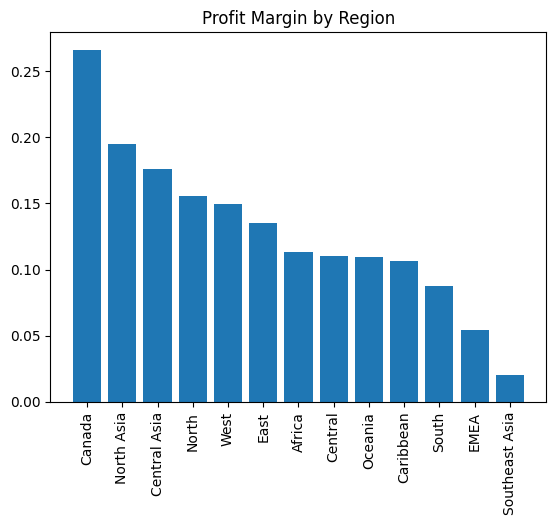

In [12]:
import matplotlib.pyplot as plt

region_summary_sorted = region_summary.sort_values("Profit Margin", ascending=False)

plt.figure()
plt.bar(region_summary_sorted.index, region_summary_sorted["Profit Margin"])
plt.xticks(rotation=90)
plt.title("Profit Margin by Region")
plt.show()


Doing this we can see that:



*   The region with the most margin is Canada
*   The region with most sales is Central


*   The region that sells a lot but has a low margin is South ans SouthAsia





## 4. Discount Impact Analysis
We investigate how discount levels influence average profitability.


Now we are going to analyze if the discounts affect the Profit


*   Discount vs Profit



In [13]:
discount_profit = df.groupby("Discount")["Profit"].mean()
print(discount_profit)


Discount
0.000      61.039514
0.002     125.762649
0.070     140.990022
0.100      63.683426
0.150      50.602409
0.170      38.317107
0.200      23.552594
0.202     -14.518847
0.250       4.043371
0.270      -4.317213
0.300     -57.899557
0.320     -88.560656
0.350    -116.144693
0.370     -78.462191
0.400     -45.246603
0.402    -109.908138
0.450     -41.610973
0.470     -42.982420
0.500     -97.140158
0.550    -315.067200
0.570    -526.129000
0.600     -81.732147
0.602    -213.279085
0.650    -365.997971
0.700    -104.339576
0.800    -122.203244
0.850   -1534.329000
Name: Profit, dtype: float64


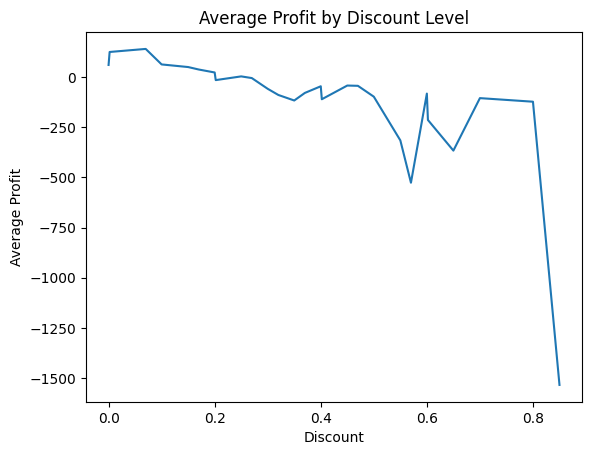

In [18]:
plt.figure()
plt.plot(discount_profit.index, discount_profit.values)
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.title("Average Profit by Discount Level")
plt.show()


We can see that when the discount is higher, the profit lowers. When it reaches a discount of 30% , the company starts getting loses.



*   Now we are going to search for wich region applies more discount




In [15]:
discount_by_region = df.groupby("Region")["Discount"].mean().sort_values(ascending=False)
print(discount_by_region)


Region
Southeast Asia    0.272077
EMEA              0.196083
Africa            0.156704
Oceania           0.153169
South             0.149050
East              0.145365
Central           0.138851
Caribbean         0.135751
West              0.109335
North             0.096056
Central Asia      0.067480
North Asia        0.048717
Canada            0.000000
Name: Discount, dtype: float64


The low profitability in Southeast Asia appears to be driven by aggressive discounting strategies.

## 5. Key Insights & Business Recommendations

### Key Findings
- Central generates the highest total sales and profit.
- Canada shows the highest profit margin despite low sales volume.
- Southeast Asia applies the highest discounts and has the lowest profitability.
- Profit declines significantly when discounts exceed 30%.

### Recommendations
- Reassess aggressive discount strategies in Southeast Asia.
- Explore scaling operations in Canada due to high efficiency.
- Monitor discount thresholds to prevent margin erosion.
